# 04 — Scratch CNN Eğitimi
PosterCNN (4-blok) + CutMix/MixUp + AdamW + CosineAnnealingLR + Early Stopping

In [1]:
import pickle
from pathlib import Path

# --- Yerel ---
CODE_ROOT = Path("../")
DATA_ROOT = Path("../")

# --- Colab ---
# from google.colab import drive
# drive.mount('/content/drive')
# CODE_ROOT = Path('/content/drive/MyDrive/film-genre-project')
# DATA_ROOT = Path('/content/drive/MyDrive/film-genre-project-data')
# import sys; sys.path.insert(0, str(CODE_ROOT / 'src'))

import sys
sys.path.insert(0, str(CODE_ROOT / "src"))

POSTERS_DIR = DATA_ROOT / "posters"
TRAIN_CSV   = DATA_ROOT / "train.csv"
VAL_CSV     = DATA_ROOT / "val.csv"
MLB_PKL     = DATA_ROOT / "mlb.pkl"
CKPT_DIR    = CODE_ROOT / "checkpoints" / "scratch"

with open(MLB_PKL, "rb") as f:
    mlb = pickle.load(f)

N_CLASSES = len(mlb.classes_)
print(f"N_CLASSES={N_CLASSES}  classes={mlb.classes_.tolist()}")

N_CLASSES=15  classes=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Mystery', 'Romance', 'Science Fiction', 'Thriller']


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader

from dataset import PosterDataset
from model import PosterCNN
from loss import build_loss
from train import train, _make_sampler
from transforms import train_transforms, val_transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


## 1. Dataset

In [3]:
BATCH_SIZE  = 64
NUM_WORKERS = 2

train_ds = PosterDataset(TRAIN_CSV, POSTERS_DIR, mlb, transform=train_transforms)
val_ds   = PosterDataset(VAL_CSV,   POSTERS_DIR, mlb, transform=val_transforms)

print(f"Train: {len(train_ds):,}  Val: {len(val_ds):,}")

Train: 8,466  Val: 1,818


## 2. CutMix / MixUp yardımcıları

In [4]:
def cutmix_batch(imgs, labels, alpha=1.0):
    """CutMix — rastgele dikdörtgen bölgeyi başka bir örnekten yapıştırır."""
    lam = np.random.beta(alpha, alpha)
    B, C, H, W = imgs.shape
    perm = torch.randperm(B, device=imgs.device)

    cut_h = int(H * np.sqrt(1 - lam))
    cut_w = int(W * np.sqrt(1 - lam))
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    x1, x2 = max(cx - cut_w // 2, 0), min(cx + cut_w // 2, W)
    y1, y2 = max(cy - cut_h // 2, 0), min(cy + cut_h // 2, H)

    imgs_out = imgs.clone()
    imgs_out[:, :, y1:y2, x1:x2] = imgs[perm, :, y1:y2, x1:x2]

    lam_actual = 1.0 - (x2 - x1) * (y2 - y1) / (W * H)
    labels_out = lam_actual * labels + (1 - lam_actual) * labels[perm]
    return imgs_out, labels_out


def mixup_batch(imgs, labels, alpha=0.4):
    """MixUp — iki örneği piksel ve etiket düzeyinde karıştırır."""
    lam = np.random.beta(alpha, alpha)
    perm = torch.randperm(imgs.size(0), device=imgs.device)
    imgs_out   = lam * imgs   + (1 - lam) * imgs[perm]
    labels_out = lam * labels + (1 - lam) * labels[perm]
    return imgs_out, labels_out


print("CutMix ve MixUp tanımlandı")

CutMix ve MixUp tanımlandı


## 3. Eğitim döngüsü (CutMix/MixUp dahil)

In [5]:
from sklearn.metrics import f1_score

CFG = {
    "epochs":         50,
    "warmup_epochs":  3,
    "batch_size":     BATCH_SIZE,
    "num_workers":    NUM_WORKERS,
    "lr":             5e-4,  # 1e-3 → 5e-4
    "weight_decay":   1e-4,
    "patience":       10,
    "cutmix_prob":    0.0,   # kapalı — önce temiz converge
    "mixup_prob":     0.0,   # kapalı — önce temiz converge
    "focal_loss":     False,
}

# pos_weight: max 5x ile sınırla (14x gibi aşırı değerler eğitimi bozuyor)
label_sums = train_ds.labels.sum(axis=0)
pos_weight = torch.tensor(
    (len(train_ds) - label_sums) / (label_sums + 1e-6),
    dtype=torch.float32,
).clamp(max=5.0).to(DEVICE)

model     = PosterCNN(n_classes=N_CLASSES).to(DEVICE)
criterion = build_loss(pos_weight=pos_weight, focal=CFG["focal_loss"])
optimizer = torch.optim.AdamW(
    model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"]
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG["epochs"] - CFG["warmup_epochs"]
)

sampler      = _make_sampler(train_ds)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

CKPT_DIR.mkdir(parents=True, exist_ok=True)
ckpt_path = CKPT_DIR / "best.pt"

history   = {"train_loss": [], "val_macro_f1": []}
best_f1, no_improve = 0.0, 0


def eval_macro_f1(mdl, loader):
    mdl.eval()
    preds_all, targets_all = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            preds_all.append(
                (torch.sigmoid(mdl(imgs.to(DEVICE))) > 0.5).cpu().numpy()
            )
            targets_all.append(labels.numpy())
    return f1_score(np.vstack(targets_all), np.vstack(preds_all),
                    average="macro", zero_division=0)


for epoch in range(1, CFG["epochs"] + 1):
    # Warmup
    if epoch <= CFG["warmup_epochs"]:
        for pg in optimizer.param_groups:
            pg["lr"] = CFG["lr"] * epoch / CFG["warmup_epochs"]

    model.train()
    total_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        r = np.random.rand()
        if r < CFG["cutmix_prob"]:
            imgs, labels = cutmix_batch(imgs, labels)
        elif r < CFG["cutmix_prob"] + CFG["mixup_prob"]:
            imgs, labels = mixup_batch(imgs, labels)

        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if epoch > CFG["warmup_epochs"]:
        scheduler.step()

    val_f1   = eval_macro_f1(model, val_loader)
    avg_loss = total_loss / len(train_loader)
    history["train_loss"].append(avg_loss)
    history["val_macro_f1"].append(val_f1)
    print(f"Epoch {epoch:2d}/{CFG['epochs']}  "
          f"loss={avg_loss:.4f}  val_macro_f1={val_f1:.4f}  "
          f"lr={optimizer.param_groups[0]['lr']:.2e}")

    if val_f1 > best_f1:
        best_f1, no_improve = val_f1, 0
        torch.save(model.state_dict(), ckpt_path)
    else:
        no_improve += 1
        if no_improve >= CFG["patience"]:
            print(f"Early stopping at epoch {epoch}")
            break

print(f"\nBest val Macro F1: {best_f1:.4f}")

Epoch  1/50  loss=2.1903  val_macro_f1=0.2063  lr=1.67e-04
Epoch  2/50  loss=1.2200  val_macro_f1=0.2059  lr=3.33e-04
Epoch  3/50  loss=1.0840  val_macro_f1=0.1641  lr=5.00e-04
Epoch  4/50  loss=1.0582  val_macro_f1=0.2095  lr=4.99e-04
Epoch  5/50  loss=1.0420  val_macro_f1=0.1960  lr=4.98e-04
Epoch  6/50  loss=1.0309  val_macro_f1=0.2093  lr=4.95e-04
Epoch  7/50  loss=1.0315  val_macro_f1=0.2131  lr=4.91e-04
Epoch  8/50  loss=1.0202  val_macro_f1=0.2359  lr=4.86e-04
Epoch  9/50  loss=1.0210  val_macro_f1=0.2404  lr=4.80e-04
Epoch 10/50  loss=1.0174  val_macro_f1=0.2385  lr=4.73e-04
Epoch 11/50  loss=1.0105  val_macro_f1=0.2487  lr=4.65e-04
Epoch 12/50  loss=1.0101  val_macro_f1=0.2565  lr=4.56e-04
Epoch 13/50  loss=1.0088  val_macro_f1=0.2440  lr=4.46e-04
Epoch 14/50  loss=1.0078  val_macro_f1=0.2601  lr=4.35e-04
Epoch 15/50  loss=1.0064  val_macro_f1=0.2558  lr=4.24e-04
Epoch 16/50  loss=1.0040  val_macro_f1=0.2689  lr=4.11e-04
Epoch 17/50  loss=0.9967  val_macro_f1=0.2725  lr=3.98e-

## 4. Eğitim eğrileri

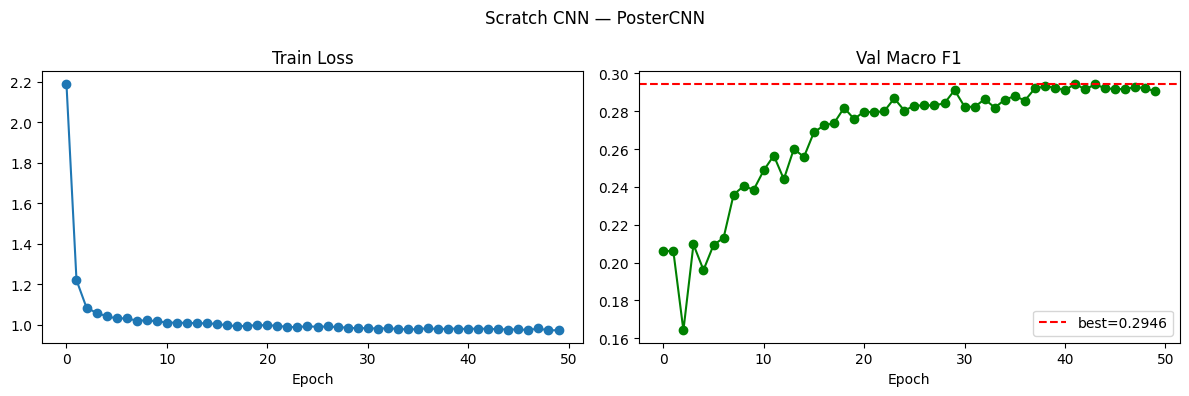

Son 5 epoch ortalama train loss: 0.9754
Best val F1: 0.2946


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], marker="o")
ax1.set_title("Train Loss")
ax1.set_xlabel("Epoch")

ax2.plot(history["val_macro_f1"], marker="o", color="green")
ax2.set_title("Val Macro F1")
ax2.set_xlabel("Epoch")
ax2.axhline(best_f1, linestyle="--", color="red", label=f"best={best_f1:.4f}")
ax2.legend()

plt.suptitle("Scratch CNN — PosterCNN")
plt.tight_layout()
plt.show()

# Overfit kontrolü
if len(history["train_loss"]) > 5:
    late_loss = np.mean(history["train_loss"][-5:])
    print(f"Son 5 epoch ortalama train loss: {late_loss:.4f}")
    print(f"Best val F1: {best_f1:.4f}")
    if late_loss < 0.1 and best_f1 < 0.2:
        print("UYARI: Muhtemel overfitting — augmentation/dropout artır")

## 5. Focal Loss ile yeniden eğitim (isteğe bağlı)
Azınlık sınıflar öğrenilmiyorsa çalıştır.

In [7]:
# Bu hücreyi yalnızca baseline val F1 < 0.15 ise çalıştır
# CFG["focal_loss"] = True
# model = PosterCNN(n_classes=N_CLASSES).to(DEVICE)
# criterion = build_loss(pos_weight=pos_weight, focal=True, gamma=2.0)
# ... (yukarıdaki hücreyi tekrar çalıştır)
print("Gerekirse CFG['focal_loss'] = True yapıp üstteki hücreyi yeniden çalıştır.")

Gerekirse CFG['focal_loss'] = True yapıp üstteki hücreyi yeniden çalıştır.


In [8]:
# Best checkpoint'i yükle
model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
print(f"Checkpoint yüklendi — başlangıç F1: {best_f1:.4f}")

CONT_EPOCHS = 40
CONT_LR     = 2e-4

optimizer2 = torch.optim.AdamW(
    model.parameters(), lr=CONT_LR, weight_decay=1e-4
)
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer2, T_max=CONT_EPOCHS
)

CUTMIX_PROB = 0.3
MIXUP_PROB  = 0.1
PATIENCE    = 10

history2        = {"train_loss": [], "val_macro_f1": []}
best_f1_cont    = best_f1
no_improve_cont = 0

for epoch in range(1, CONT_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        r = np.random.rand()
        if r < CUTMIX_PROB:
            imgs, labels = cutmix_batch(imgs, labels)
        elif r < CUTMIX_PROB + MIXUP_PROB:
            imgs, labels = mixup_batch(imgs, labels)

        optimizer2.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer2.step()
        total_loss += loss.item()

    scheduler2.step()

    val_f1   = eval_macro_f1(model, val_loader)
    avg_loss = total_loss / len(train_loader)
    history2["train_loss"].append(avg_loss)
    history2["val_macro_f1"].append(val_f1)
    print(f"Cont {epoch:2d}/{CONT_EPOCHS}  "
          f"loss={avg_loss:.4f}  val_macro_f1={val_f1:.4f}  "
          f"lr={optimizer2.param_groups[0]['lr']:.2e}")

    if val_f1 > best_f1_cont:
        best_f1_cont, no_improve_cont = val_f1, 0
        torch.save(model.state_dict(), ckpt_path)
        print(f"  ✓ Yeni best: {best_f1_cont:.4f}")
    else:
        no_improve_cont += 1
        if no_improve_cont >= PATIENCE:
            print(f"Early stopping at cont epoch {epoch}")
            break

print(f"\nContinuation best val Macro F1: {best_f1_cont:.4f}")
print(f"İyileşme: {best_f1:.4f} → {best_f1_cont:.4f} (+{best_f1_cont - best_f1:.4f})")

Checkpoint yüklendi — başlangıç F1: 0.2946
Cont  1/40  loss=1.0009  val_macro_f1=0.2845  lr=2.00e-04
Cont  2/40  loss=0.9914  val_macro_f1=0.2905  lr=1.99e-04
Cont  3/40  loss=0.9907  val_macro_f1=0.2886  lr=1.97e-04
Cont  4/40  loss=0.9923  val_macro_f1=0.2861  lr=1.95e-04
Cont  5/40  loss=0.9920  val_macro_f1=0.2919  lr=1.92e-04
Cont  6/40  loss=0.9978  val_macro_f1=0.2882  lr=1.89e-04
Cont  7/40  loss=0.9983  val_macro_f1=0.2915  lr=1.85e-04
Cont  8/40  loss=0.9925  val_macro_f1=0.2910  lr=1.81e-04
Cont  9/40  loss=0.9896  val_macro_f1=0.2890  lr=1.76e-04
Cont 10/40  loss=0.9996  val_macro_f1=0.2876  lr=1.71e-04
Early stopping at cont epoch 10

Continuation best val Macro F1: 0.2946
İyileşme: 0.2946 → 0.2946 (+0.0000)
